In [1]:
# Import required libraries
import torch
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import time
import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint
import importlib


In [2]:

# Add current directory to path to import our modules
if '.' not in sys.path:
    sys.path.append('.')

# Import our modules
from models import ObjectDetectionModel, ObjectDetectionDataModule
from utils import plot_image
# from onnx_conversion import export_to_onnx, verify_onnx_model


In [3]:

# reload modules to get the latest changes
import models
import utils
# import onnx_conversion
import dataset

importlib.reload(models)
importlib.reload(utils)
# importlib.reload(onnx_conversion)
importlib.reload(dataset)

from models import ObjectDetectionModel, ObjectDetectionDataModule, LightweightGridDetectionModel, SafetyLosses, LightweightGridDetectionModelUYVY, ObjectDetectionDataModuleUYVY 
from utils import plot_image, plot_side_by_side, compare_pytorch_onnx_side_by_side
# from onnx_conversion import export_to_onnx, verify_onnx_model
from dataset import CustomImageDataset, CustomImageDatasetUYVY


# Step 0: Initialize the model and data module

In [4]:

import os
import torch
import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Define constants
width = 520  # Original width
height = 240
image_dir_train = "./dataset_uyvy/images/train"
image_dir_val = "./dataset_uyvy/images/val"

# Set up grid lines
grid_lines = [[0, 0.2, 0.4, 0.6, 0.8, 1], [0, 1]]
grid_lines[0] = [line * width for line in grid_lines[0]]  # Use original width for grid lines
grid_lines[1] = [line * height for line in grid_lines[1]]
danger_levels = 3

# Training parameters
max_epochs = 100
batch_size = 16
checkpoint_path = "./model_checkpoints_uyvy"  # New checkpoint directory for UYVY model
os.makedirs(checkpoint_path, exist_ok=True)

# Create checkpoint callback
checkpoint_callback = ModelCheckpoint(
    dirpath=checkpoint_path,
    filename='uyvy_detection-{epoch:02d}-{val_loss:.2f}',
    save_top_k=3,
    monitor='val_loss',
    mode='min'
)

# Training flag - set to True if you want to train the model, False to load a saved model
train_model = True

# Initialize UYVY-compatible model
model = LightweightGridDetectionModelUYVY(
    grid_lines=grid_lines,
    input_shape=(1, height, width*2),  # Modified for UYVY format
    learning_rate=0.001
)

# Then update the data module initialization
data_module = ObjectDetectionDataModuleUYVY(
    image_dir_train=image_dir_train,
    image_dir_val=image_dir_val,
    width=width,
    height=height,
    grid_lines=grid_lines,
    batch_size=batch_size,
    device=device
)

Using device: cpu


# Step 1: Investigate Dataset
# Class balance

In [5]:
def analyze_dataset(data_module):
    data_module.setup()

    
    print("Dataset Statistics:")
    print(f"Training samples: {len(data_module.train_dataset)}")
    print(f"Validation samples: {len(data_module.val_dataset)}")
    
    # Analyze label distribution
    all_labels = []
    for _, labels in data_module.train_dataloader():
        all_labels.append(labels.cpu().numpy())
    all_labels = np.concatenate(all_labels)
    
    print("\nLabel Statistics:")
    print(f"Label shape: {all_labels.shape}")
    
    # Calculate class distribution
    safe_ratio = np.mean(all_labels[:, 0] > 0.5)
    warning_ratio = np.mean(all_labels[:, 1] > 0.5)
    danger_ratio = np.mean(all_labels[:, 2] > 0.5)
    
    print("\nClass Distribution (using 0.5 threshold):")
    print(f"Safe cells: {safe_ratio:.2%}")
    print(f"Warning cells: {warning_ratio:.2%}")
    print(f"Danger cells: {danger_ratio:.2%}")
    
    # Check for potential issues
    print("\nPotential Issues:")
    print(f"NaN values: {np.isnan(all_labels).any()}")
    print(f"Inf values: {np.isinf(all_labels).any()}")

analyze_dataset(data_module)

Dataset Statistics:
Training samples: 255
Validation samples: 63

Label Statistics:
Label shape: (255, 3, 5, 1)

Class Distribution (using 0.5 threshold):
Safe cells: 81.65%
Warning cells: 8.94%
Danger cells: 9.41%

Potential Issues:
NaN values: False
Inf values: False


# Label exclusivity

In [6]:
from models import DangerLevelConfig

def analyze_label_exclusivity(data_module):
    data_module.setup()
    
    total_cells = 0
    config = DangerLevelConfig()
    
    # Initialize class combinations counter
    class_combinations = {
        f'{level["name"].lower()}_only': 0 for level in config.LEVEL_DEFINITIONS
    }
    class_combinations['no_label'] = 0
    
    # For validation purposes, still check for overlaps
    non_exclusive = 0
    confusion_matrix = np.zeros((len(config.LEVEL_DEFINITIONS), len(config.LEVEL_DEFINITIONS)))
    
    for _, labels in data_module.train_dataloader():
        labels = labels.cpu().numpy()
        batch_size, classes, grid_x, grid_y = labels.shape
        total_cells += batch_size * grid_x * grid_y
        
        for b in range(batch_size):
            for x in range(grid_x):
                for y in range(grid_y):
                    cell_labels = labels[b, :, x, y]
                    active_labels = np.where(cell_labels > 0.5)[0]
                    
                    if len(active_labels) > 1:
                        # This shouldn't happen with our new implementation
                        non_exclusive += 1
                        # Record overlap for debugging
                        for i in active_labels:
                            for j in active_labels:
                                if i < j:
                                    confusion_matrix[i, j] += 1
                    elif len(active_labels) == 0:
                        class_combinations['no_label'] += 1
                    else:
                        level_name = config.LEVEL_DEFINITIONS[active_labels[0]]['name'].lower()
                        class_combinations[f'{level_name}_only'] += 1
    
    print(f"Total grid cells analyzed: {total_cells}")
    if non_exclusive > 0:
        print(f"WARNING: Found {non_exclusive} cells with overlapping labels!")
        print("This shouldn't happen with mutual exclusivity enforced.")
    
    print("\nClass distribution:")
    for combo, count in class_combinations.items():
        print(f"{combo}: {count} ({(count/total_cells)*100:.2f}%)")
    
    if non_exclusive > 0:
        print("\nUnexpected overlap patterns found:")
        level_names = [level['name'] for level in config.LEVEL_DEFINITIONS]
        for i in range(len(config.LEVEL_DEFINITIONS)):
            for j in range(i+1, len(config.LEVEL_DEFINITIONS)):
                if confusion_matrix[i, j] > 0:
                    print(f"{level_names[i]} + {level_names[j]}: {int(confusion_matrix[i, j])} instances")

    return class_combinations, confusion_matrix

# Run the analysis
results = analyze_label_exclusivity(data_module)

Total grid cells analyzed: 1275

Class distribution:
danger_only: 1041 (81.65%)
warning_only: 114 (8.94%)
safe_only: 120 (9.41%)
no_label: 0 (0.00%)


In [7]:
def visualize_overlapping_labels(data_module, num_examples=3):
    data_module.setup()
    
    for _, (images, labels) in enumerate(data_module.train_dataloader()):
        batch_size = images.shape[0]
        for i in range(batch_size):
            # Check for overlapping labels
            label = labels[i]  # [3, grid_x, grid_y]
            has_overlap = False
            for x in range(label.shape[1]):
                for y in range(label.shape[2]):
                    cell_labels = label[:, x, y]
                    if sum(cell_labels > 0.5) > 1:
                        has_overlap = True
                        break
                if has_overlap:
                    break
            
            if has_overlap:
                # Create figure with 5 subplots:
                # Original image, Safe channel, Warning channel, Danger channel, Combined
                fig, axes = plt.subplots(1, 5, figsize=(25, 5))
                
                # Original image
                img = images[i].cpu().permute(1, 2, 0).numpy()
                axes[0].imshow(img)
                axes[0].set_title("Original Image")
                
                # Add grid lines to all plots
                for ax in axes:
                    for x in data_module.grid_lines[0]:
                        ax.axvline(x, color='blue', linestyle='--', alpha=0.3)
                    for y in data_module.grid_lines[1]:
                        ax.axhline(y, color='blue', linestyle='--', alpha=0.3)
                
                # Individual channels
                channel_names = ['Safe', 'Warning', 'Danger']
                colors = ['green', 'orange', 'red']
                
                for ch in range(3):
                    axes[ch+1].imshow(img)
                    axes[ch+1].set_title(f"{channel_names[ch]} Channel")
                    
                    # Show cells for this channel
                    for x in range(len(data_module.grid_lines[0]) - 1):
                        for y in range(len(data_module.grid_lines[1]) - 1):
                            if label[ch, x, y] > 0.5:
                                x1, x2 = data_module.grid_lines[0][x], data_module.grid_lines[0][x + 1]
                                y1, y2 = data_module.grid_lines[1][y], data_module.grid_lines[1][y + 1]
                                axes[ch+1].fill_between([x1, x2], [y1, y1], [y2, y2], 
                                                      color=colors[ch], alpha=0.4)
                
                # Combined visualization
                axes[4].imshow(img)
                axes[4].set_title("Combined (Overlapping)")
                
                # Show all active cells with different hatching patterns
                for x in range(len(data_module.grid_lines[0]) - 1):
                    for y in range(len(data_module.grid_lines[1]) - 1):
                        x1, x2 = data_module.grid_lines[0][x], data_module.grid_lines[0][x + 1]
                        y1, y2 = data_module.grid_lines[1][y], data_module.grid_lines[1][y + 1]
                        
                        # Create different hatch patterns for overlapping regions
                        active_channels = [ch for ch in range(3) if label[ch, x, y] > 0.5]
                        if len(active_channels) > 1:
                            for idx, ch in enumerate(active_channels):
                                axes[4].fill_between([x1, x2], [y1, y1], [y2, y2],
                                                   color=colors[ch], alpha=0.3,
                                                   hatch=['/', '\\', 'x'][idx])
                
                # Add legend to combined plot
                from matplotlib.patches import Patch
                legend_elements = [Patch(facecolor=color, alpha=0.4, label=name)
                                 for color, name in zip(colors, channel_names)]
                axes[4].legend(handles=legend_elements, loc='upper right')
                
                plt.tight_layout()
                plt.show()
                
                # Print the label values for overlapping cells
                print("\nOverlapping cell values:")
                for x in range(label.shape[1]):
                    for y in range(label.shape[2]):
                        cell_labels = label[:, x, y]
                        if sum(cell_labels > 0.5) > 1:
                            print(f"Grid cell [{x},{y}]: Safe={cell_labels[0]:.1f}, "
                                  f"Warning={cell_labels[1]:.1f}, Danger={cell_labels[2]:.1f}")
                
                num_examples -= 1
                if num_examples <= 0:
                    return

# Run the visualization
visualize_overlapping_labels(data_module)

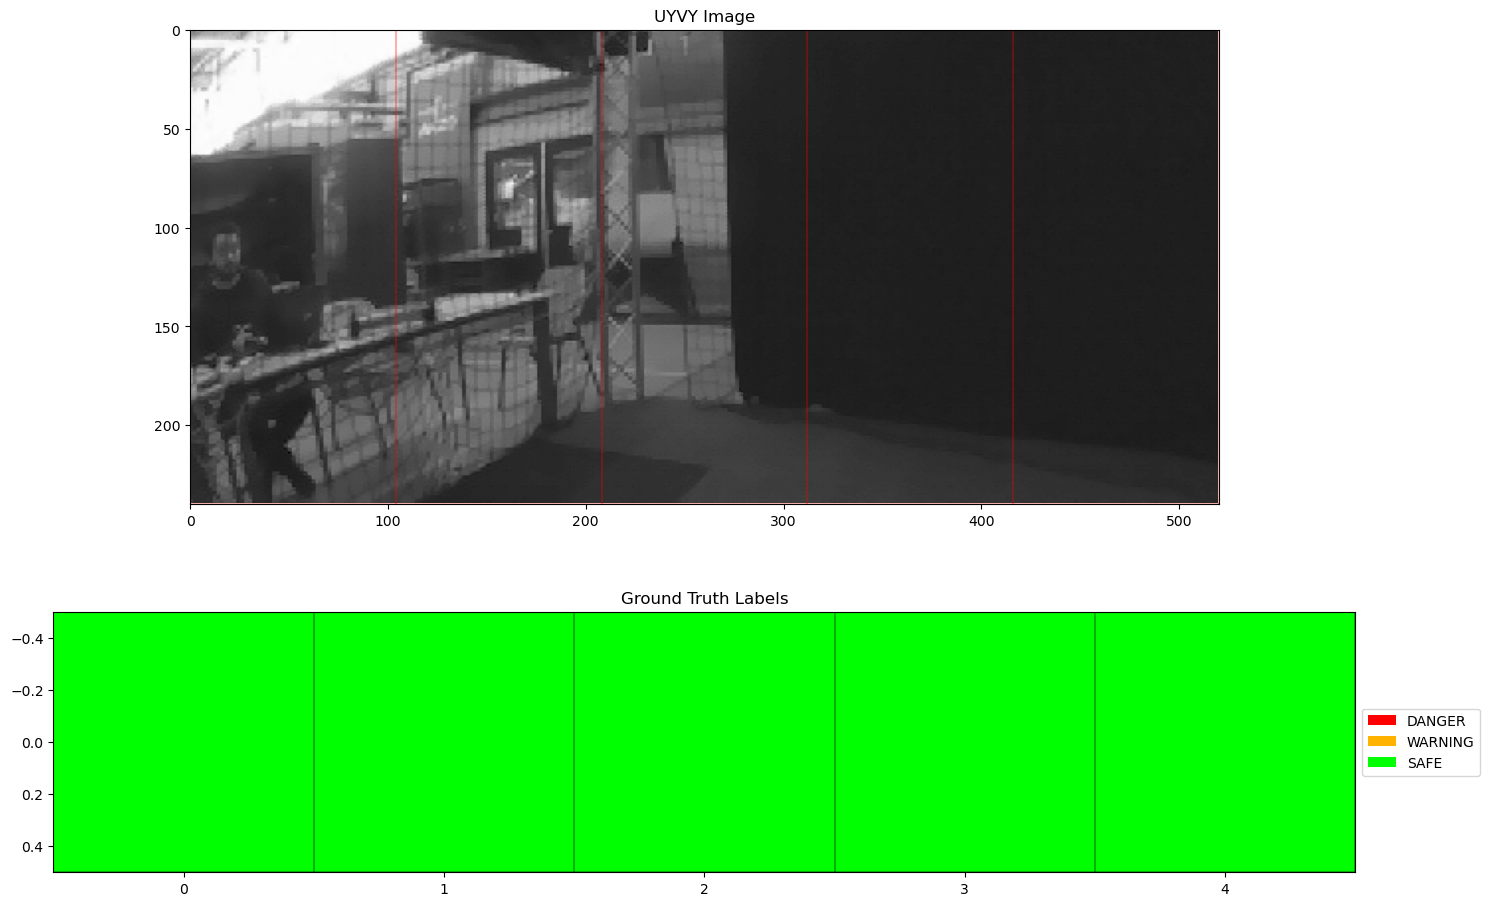

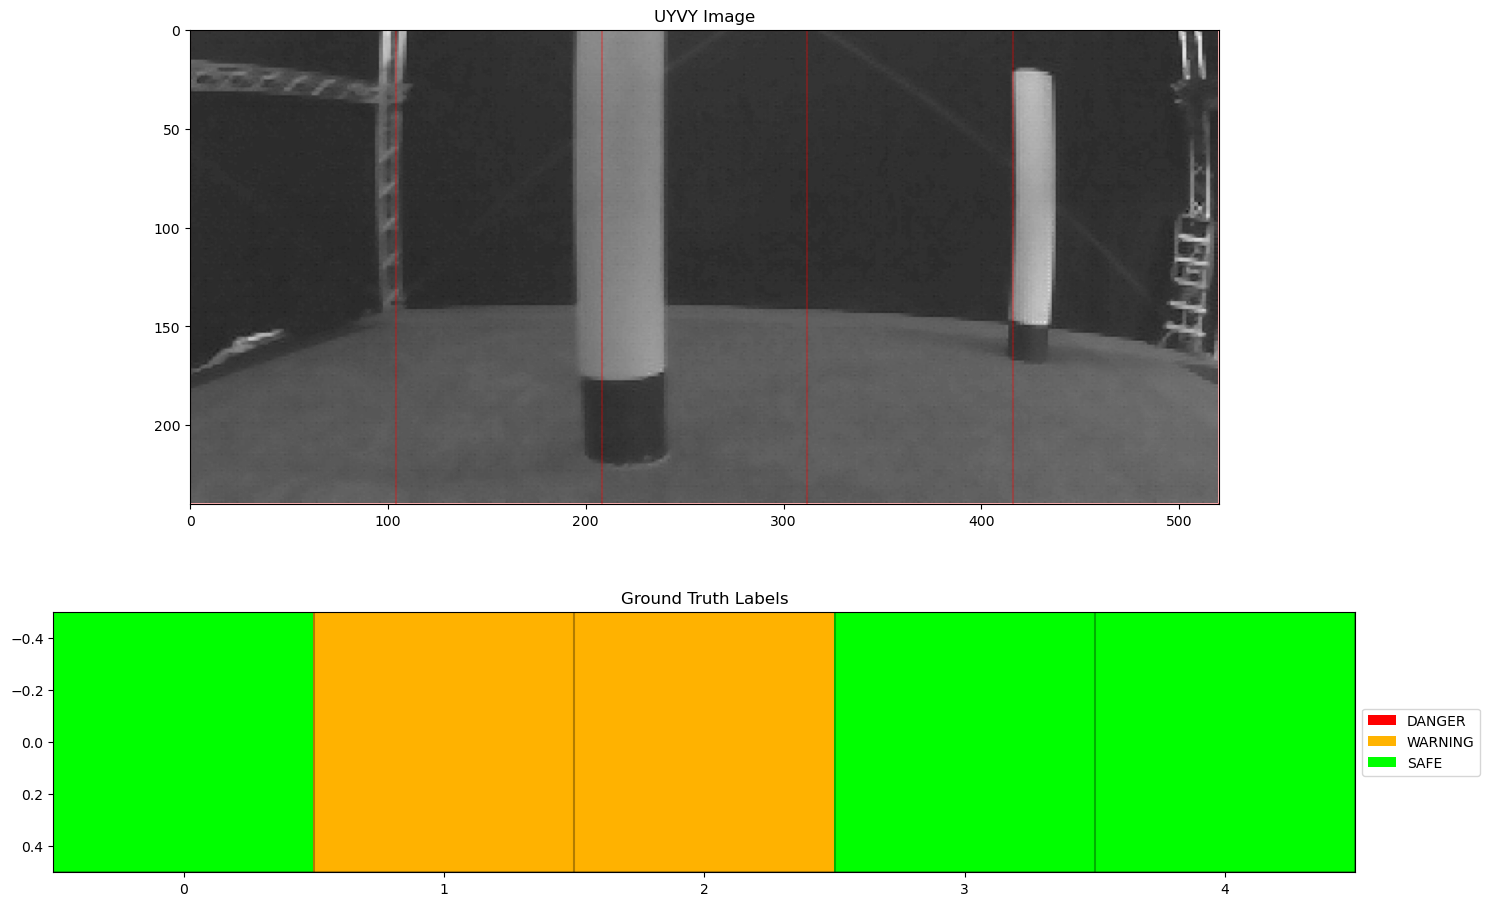

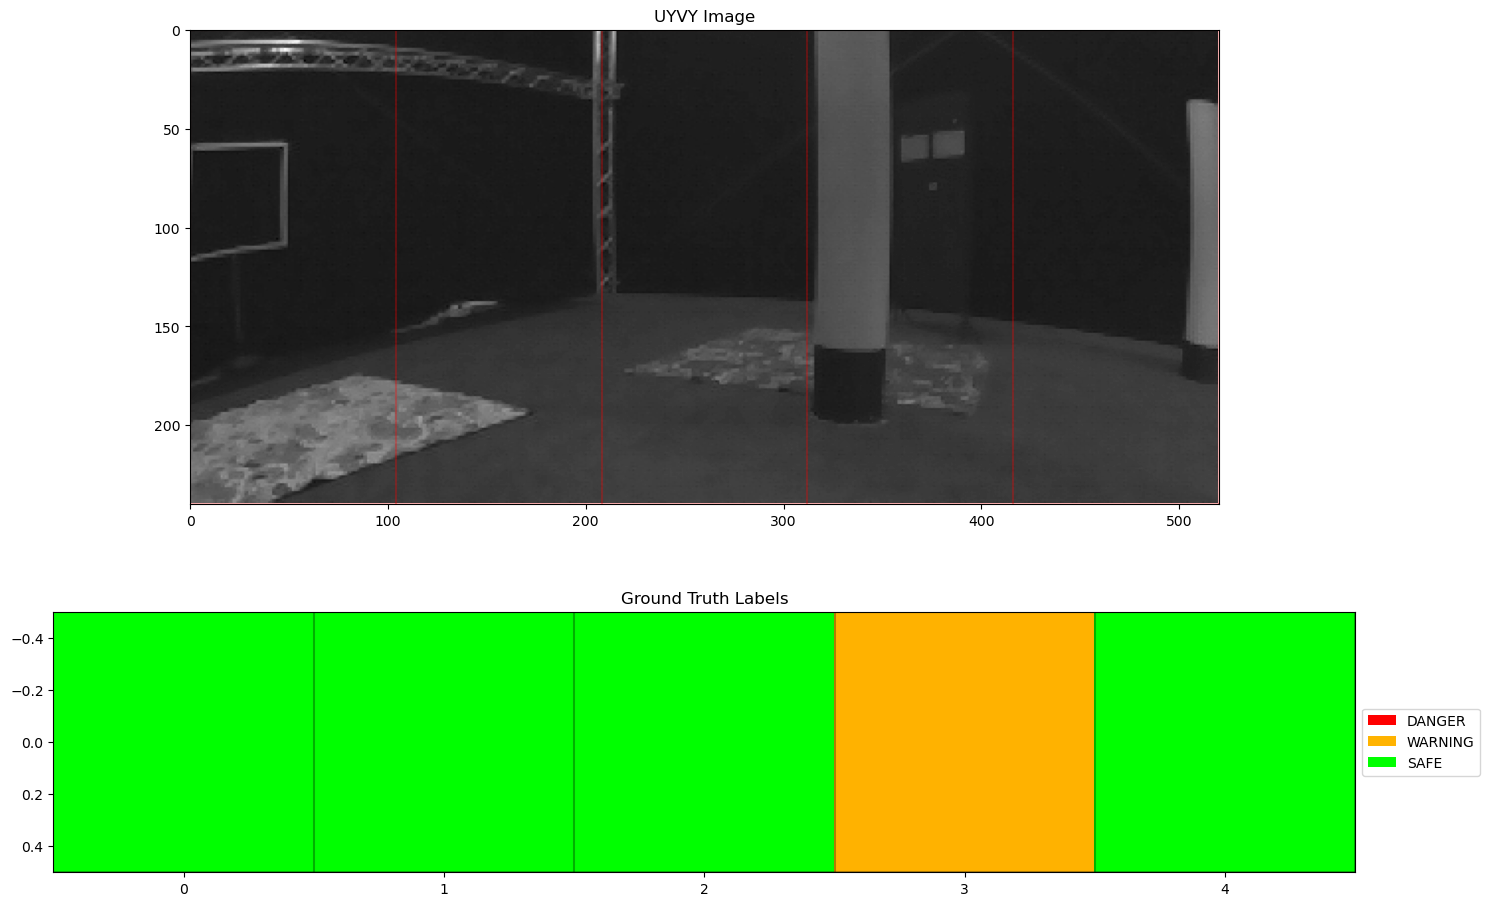

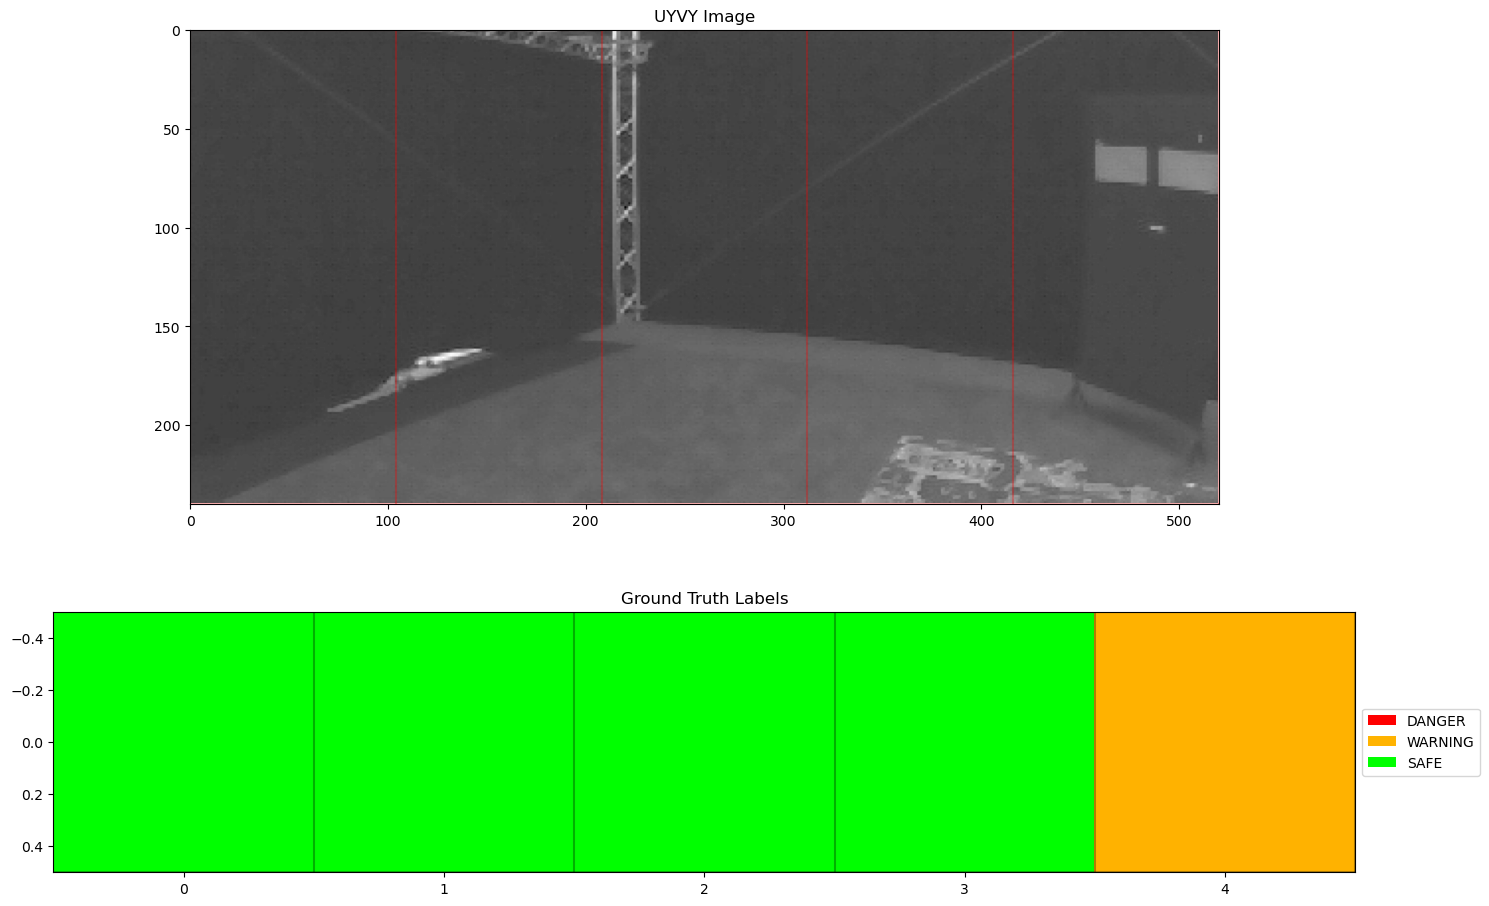

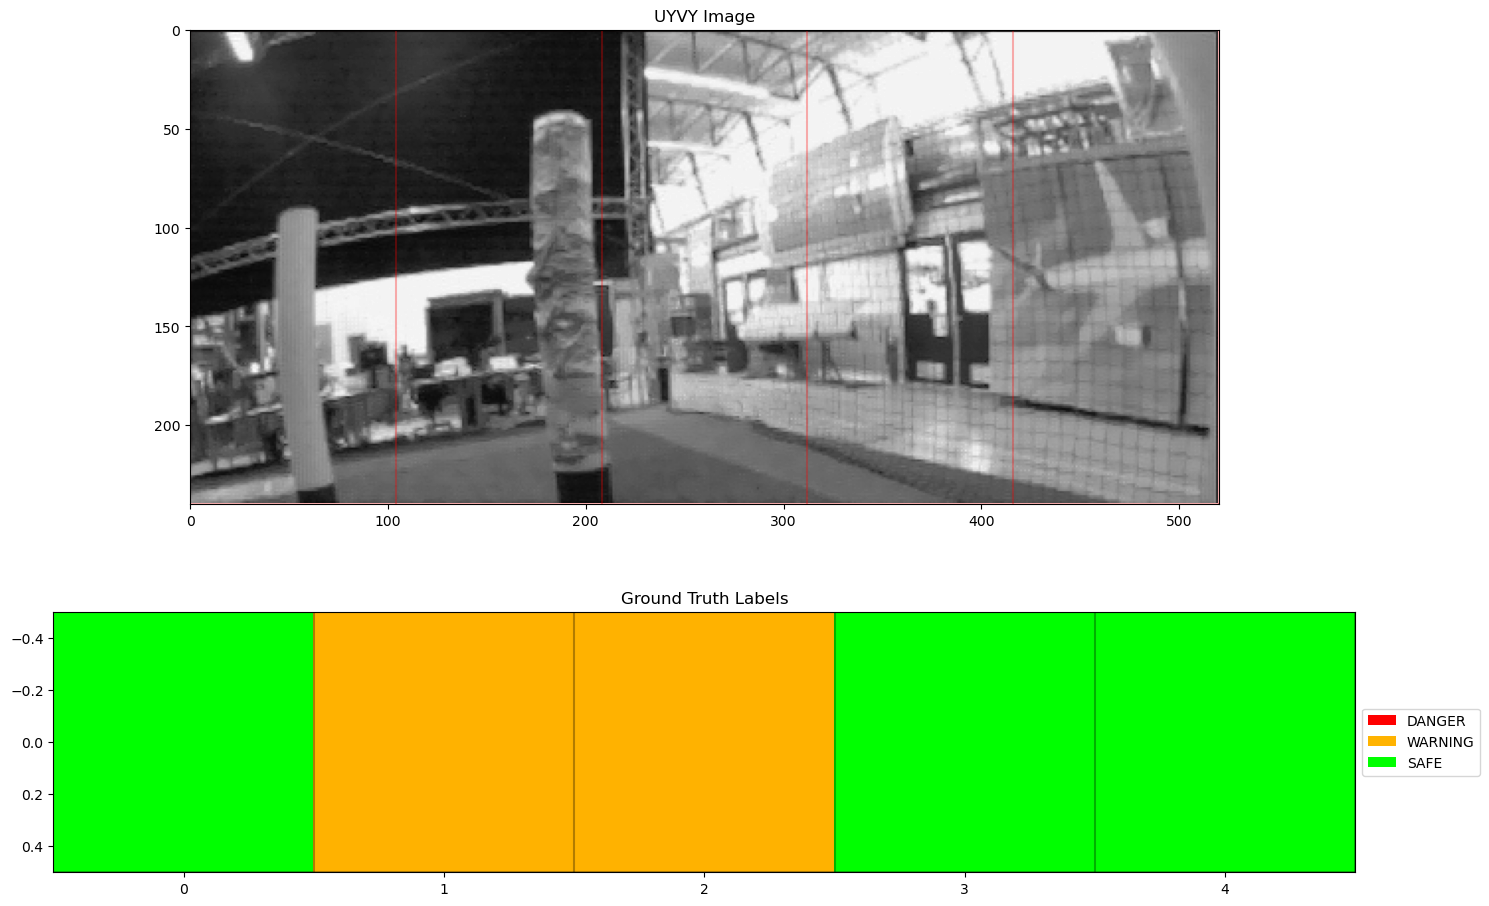

In [8]:
def visualize_sample(image, labels, grid_lines):
    """
    Visualizes a UYVY image and its ground truth labels.
    """
    config = DangerLevelConfig()
    
    # Create figure with two subplots
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10))
    
    # Plot UYVY image
    gray_image = image[::, 1::2].cpu().numpy()
    ax1.imshow(gray_image, cmap='gray')
    ax1.set_title('UYVY Image')
    
    # Double the x-coordinates for grid lines to match UYVY format
    uyvy_grid_lines = [
        [x*2 for x in grid_lines[0]],  # Double x coordinates for UYVY
        grid_lines[1]  # y coordinates remain the same
    ]
    
    # Add grid lines to image
    for x in uyvy_grid_lines[0]:
        ax1.axvline(x/2, color='r', alpha=0.3)  # Divide by 2 because we're showing Y values only
    for y in uyvy_grid_lines[1]:
        ax1.axhline(y, color='r', alpha=0.3)
    
    # Set correct aspect ratio and limits
    ax1.set_xlim(0, gray_image.shape[1])
    ax1.set_ylim(gray_image.shape[0], 0)
    
    # Plot ground truth labels
    num_columns = len(grid_lines[0]) - 1
    num_rows = len(grid_lines[1]) - 1
    grid = np.zeros((num_rows, num_columns, 3))
    
    labels = labels.cpu().numpy()
    
    colors = {
        'DANGER': [1, 0, 0],    # Red
        'WARNING': [1, 0.7, 0],  # Orange
        'SAFE': [0, 1, 0],      # Green
    }
    
    # Fill grid with colors based on labels
    for i in range(num_columns):
        for j in range(num_rows):
            cell_color = [0.9, 0.9, 0.9]  # Light gray for empty cells
            for level in config.LEVEL_DEFINITIONS:
                if labels[level['level'], i, j] == 1:
                    cell_color = colors[level['name']]
            grid[j, i] = cell_color
    
    ax2.imshow(grid)
    ax2.set_title('Ground Truth Labels')
    
    # Add grid lines to labels
    for i in range(num_columns + 1):
        ax2.axvline(i - 0.5, color='black', alpha=0.3)
    for i in range(num_rows + 1):
        ax2.axhline(i - 0.5, color='black', alpha=0.3)
    
    # Add text labels for danger levels
    legend_elements = [plt.Rectangle((0, 0), 1, 1, fc=color) 
                      for color in colors.values()]
    ax2.legend(legend_elements, colors.keys(), 
              loc='center left', bbox_to_anchor=(1, 0.5))
    
    plt.tight_layout()
    return fig

# Visualize a few examples
data_module.setup()
train_loader = data_module.train_dataloader()

# Get a few samples
num_samples = 5
samples = []
for batch in train_loader:
    if len(samples) >= num_samples:
        break
    images, labels = batch
    for i in range(len(images)):
        if len(samples) >= num_samples:
            break
        samples.append((images[i], labels[i]))

# Plot each sample
for i, (image, labels) in enumerate(samples):
    fig = visualize_sample(image, labels, grid_lines)
    plt.show()
    plt.close()

# Step 2: Train the model or load from checkpoint

# Investigate Hierarchal Loss Functions


In [9]:
import pytorch_lightning as pl
import torch
import os
from collections import defaultdict
import contextlib
import io
import logging
import warnings
from pytorch_lightning.callbacks import ModelCheckpoint

# Custom callback to log metrics
class MetricsCallback(pl.Callback):
    def __init__(self):
        super().__init__()
        self.metrics_history = defaultdict(list)
        
    def on_validation_epoch_end(self, trainer, pl_module):
        metrics = trainer.callback_metrics
        for key, value in metrics.items():
            if isinstance(value, torch.Tensor):
                self.metrics_history[key].append(value.item())
            else:
                self.metrics_history[key].append(value)

def suppress_lightning_logs(debug=False):
    """Context manager to suppress Lightning logs and warnings unless debug=True"""
    class NoOp:
        def __enter__(self): pass
        def __exit__(self, *args): pass

    if debug:
        return NoOp()
    
    logging.getLogger("pytorch_lightning").setLevel(logging.WARNING)
    os.environ["PL_GLOBAL_SEED"] = "42"
    os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
    
    return contextlib.ExitStack()

# Initialize metrics callback
metrics_callback = MetricsCallback()

# Configure checkpoint callback
checkpoint_callback = ModelCheckpoint(
    dirpath='checkpoints',
    filename='uyvy_model-{epoch:02d}-{val_loss:.2f}',
    save_top_k=3,
    monitor='val_loss',
    mode='min'
)

from pytorch_lightning.callbacks import TQDMProgressBar
from pytorch_lightning.callbacks import EarlyStopping

early_stop_callback = EarlyStopping(
    monitor='val_loss',
    mode='min',
    patience=15,  # Increased patience
    min_delta=0.01,
    verbose=True
)
# Configure trainer
trainer_kwargs = {
    'max_epochs': 100,
    'accelerator': 'gpu' if torch.cuda.is_available() else 'cpu',
    'devices': 1,
    'enable_progress_bar': True,
    'enable_model_summary': True,
    'logger': True,
    'callbacks': [metrics_callback, checkpoint_callback, TQDMProgressBar(refresh_rate=1), early_stop_callback],
    'detect_anomaly': False,
    'deterministic': False,
    'benchmark': True,
    'num_sanity_val_steps': 2
}

trainer = pl.Trainer(**trainer_kwargs)

# Train the model
with suppress_lightning_logs(debug=False):
    trainer.fit(model, data_module)
    results = trainer.validate(model, datamodule=data_module)

print("\nTraining completed!")
print(f"Best model saved at: {checkpoint_callback.best_model_path}")
print(f"Final validation results: {results[0]}")

# Store training results
training_results = {
    'model': model,
    'results': results[0],
    'training_history': metrics_callback.metrics_history,
    'best_model_path': checkpoint_callback.best_model_path
}

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/daniel/anaconda3/envs/uyvy_detection/lib/python3.8/site-packages/pytorch_lightning/trainer/connectors/logger_connector/logger_connector.py:75: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `pytorch_lightning` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
/home/daniel/anaconda3/envs/uyvy_detection/lib/python3.8/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:654: Checkpoint directory /home/daniel/Documents/GitHub/paparazzi/SmallConvNetwork/checkpoints exists and is not empty.
/home/daniel/anaconda3/envs/uyvy_detection/lib/python3.8/site-packages/torch/optim/lr_scheduler

/home/daniel/anaconda3/envs/uyvy_detection/lib/python3.8/site-packages/pytorch_lightning/loops/fit_loop.py:298: The number of training batches (16) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Validation DataLoader 0: 100%|██████████| 4/4 [00:00<00:00,  7.91it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     Validate metric           DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  val_critical_misclass     0.11428571492433548
        val_loss           -0.41948169469833374
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Training completed!
Best model saved at: /home/daniel/Documents/GitHub/paparazzi/SmallConvNetwork/checkpoints/uyvy_model-epoch=17-val_loss=-0.42.ckpt
Final validation results: {'val_loss': -0.41948169469833374, 'val_critical_misclass': 0.11428571492433548}


# Visualize


In [68]:
# import glob
# from utils import convert_coordinates

# def danger_level(x1, x2, y1, y2, label, width, height):
#     x1_rel = x1 / width
#     x2_rel = x2 / width
#     y1_rel = y1 / height
#     y2_rel = y2 / height
    
#     # Modify side distance calculation
#     if x1_rel >= 0.8:
#         side_distance = (x1_rel - 0.8) # Only penalize distance beyond 0.8
#     elif x1_rel >= 0.6:
#         side_distance = (x1_rel - 0.6) / 4  # Reduce penalty for 0.6-0.8 range
#     elif x2_rel <= 0.6:
#         side_distance = (0.6 - x2_rel) / 2
#     elif x2_rel <= 0.2:
#         side_distance = (0.6 - x2_rel) * 2
#     else:
#         side_distance = 0

#     if label == 0:
#         width_distance = (x2_rel - x1_rel) / 0.25
#         height_distance = min((y2_rel - y1_rel) / 0.8, 0.7)
#         # Reduce multiplier effect
#         multiplier = 1.5 if side_distance > 0.25 else 1
#         danger = min(max([width_distance, height_distance]) - side_distance * multiplier, 1)
#     if label == 1:
#         width_distance = (x2_rel - x1_rel) / 0.15
#         height_distance = min((y2_rel - y1_rel) / 1.1, 0.7)
#         multiplier = 1.5 if side_distance > 0.25 else 1
#         danger = min(max([width_distance, height_distance]) - side_distance * multiplier, 1)
    
#     # Ensure danger is not negative
#     danger = max(danger, 0)
    
#     return danger

# class DangerLevelConfig:
#     def __init__(self):
#         # Levels must be in descending order of danger
#         self.LEVEL_DEFINITIONS = [
#             {'name': 'DANGER', 'level': 2, 'threshold': 0.7},
#             {'name': 'WARNING', 'level': 1, 'threshold': 0.6},
#             {'name': 'SAFE', 'level': 0, 'threshold': 0.0}
#         ]
        
#         # Create convenience dictionaries
#         self.THRESHOLDS = {level['name']: level['threshold'] for level in self.LEVEL_DEFINITIONS}
#         self.LEVELS = {level['name']: level['level'] for level in self.LEVEL_DEFINITIONS}
        
#     def get_level_for_value(self, value):
#         """Returns appropriate danger level for a given danger value."""
#         for level in self.LEVEL_DEFINITIONS:
#             if value >= level['threshold']:
#                 return level['level']
#         return self.LEVELS['SAFE']  # Default to safe

# def cell_contains_bbox(bboxes, grid_lines, width, height):
#     """
#     Assigns danger levels to grid cells based on bounding boxes.
    
#     Args:
#         bboxes: List of bounding box dictionaries with keys 'label', 'x', 'y', 'w', 'h'
#         grid_lines: List of [x_lines, y_lines] defining the grid
#         width: Image width
#         height: Image height
    
#     Returns:
#         3D array of shape [num_danger_levels, num_columns, num_rows] with mutually exclusive danger levels
#     """
#     config = DangerLevelConfig()
#     num_columns = len(grid_lines[0]) - 1
#     num_rows = len(grid_lines[1]) - 1
#     num_levels = len(config.LEVELS)
    
#     # Initialize empty grid
#     box_inside_grid = [[[0 for _ in range(num_rows)] 
#                          for _ in range(num_columns)] 
#                          for _ in range(num_levels)]
    
#     def get_danger_level(danger_value):
#         """Determines the appropriate danger level based on danger value."""
#         if danger_value >= config.THRESHOLDS['DANGER']:
#             return config.LEVELS['DANGER']
#         elif danger_value >= config.THRESHOLDS['WARNING']:
#             return config.LEVELS['WARNING']
#         else:
#             return config.LEVELS['SAFE']
    
#     def box_intersects_cell(x1, x2, left, right):
#         """Checks if box intersects with cell in x-dimension."""
#         return ((left <= x1 <= right) or 
#                 (left <= x2 <= right) or 
#                 (x1 <= left and x2 >= right))
    
#     def box_intersects_cell_y(y1, y2, bottom, top):
#         """Checks if box intersects with cell in y-dimension."""
#         return ((bottom <= y1 <= top) or 
#                 (bottom <= y2 <= top) or
#                 (y1 <= bottom and y2 >= top))
    
#     # Process each bounding box
#     for bbox in bboxes:
#         x1, x2, y1, y2 = convert_coordinates(bbox, width, height)
        
#         # Check intersection with each grid cell
#         for i in range(num_columns):
#             left, right = grid_lines[0][i], grid_lines[0][i + 1]
            
#             if box_intersects_cell(x1, x2, left, right):
#                 for j in range(num_rows):
#                     bottom, top = grid_lines[1][j], grid_lines[1][j + 1]
                    
#                     if box_intersects_cell_y(y1, y2, bottom, top):
#                         danger = danger_level(x1, x2, y1, y2, bbox["label"], width, height)
#                         level = get_danger_level(danger)
#                         box_inside_grid[level][i][j] = 1

#     return box_inside_grid

# def test_with_actual_files():
#     # Configuration
#     width = 520
#     height = 240
#     grid_lines = [[0, 104.0, 208.0, 312.0, 416.0, 520], [0, 240]]
#     val_dir = "./dataset_uyvy/images/val"
#     config = DangerLevelConfig()
    
#     # Get first few label files
#     label_paths = sorted(glob.glob(val_dir.replace("images", "labels") + "/*.txt"))
    
#     for label_path in label_paths[:3]:  # Test first 3 files
#         print(f"\n=== Testing {label_path} ===")
        
#         # Read raw label file
#         with open(label_path, "r") as f:
#             raw_label = f.readline().strip()
#         print("Raw label line:", raw_label)
        
#         # Parse into bbox
#         parts = raw_label.split()
#         bbox = {
#             "label": int(parts[0]),
#             "x": int(float(parts[1]) * width),
#             "y": int(float(parts[2]) * height),
#             "w": int(float(parts[3]) * width),
#             "h": int(float(parts[4]) * height)
#         }
#         print("\nParsed bbox:", bbox)
        
#         # Convert coordinates
#         x1, x2, y1, y2 = convert_coordinates(bbox, width, height)
#         print("\nConverted coordinates:")
#         print(f"x1: {x1}, x2: {x2}, y1: {y1}, y2: {y2}")
        
#         # Calculate danger level
#         danger = danger_level(x1, x2, y1, y2, bbox["label"], width, height)
#         print("\nDanger level:", danger)
#         print(f"Assigned level: {config.get_level_for_value(danger)}")
        
#         # Get cell assignments
#         cell_dangers = cell_contains_bbox([bbox], grid_lines, width, height)
        
#         # Print results in a more structured way
#         print("\nCell danger levels:")
#         for level in config.LEVEL_DEFINITIONS:
#             level_idx = level['level']
#             print(f"\nLevel {level_idx} ({level['name']}):")
#             for row in cell_dangers[level_idx]:
#                 print(row)
            
#             # Verify mutual exclusivity
#             if level_idx > 0:
#                 for i in range(len(cell_dangers[0])):
#                     for j in range(len(cell_dangers[0][0])):
#                         if cell_dangers[level_idx][i][j] == 1:
#                             assert all(cell_dangers[other_level][i][j] == 0 
#                                      for other_level in range(len(config.LEVEL_DEFINITIONS)) 
#                                      if other_level != level_idx), \
#                                 f"Cell [{i},{j}] has multiple danger levels!"

# # Run the test
# test_with_actual_files()


=== Sample 1 ===


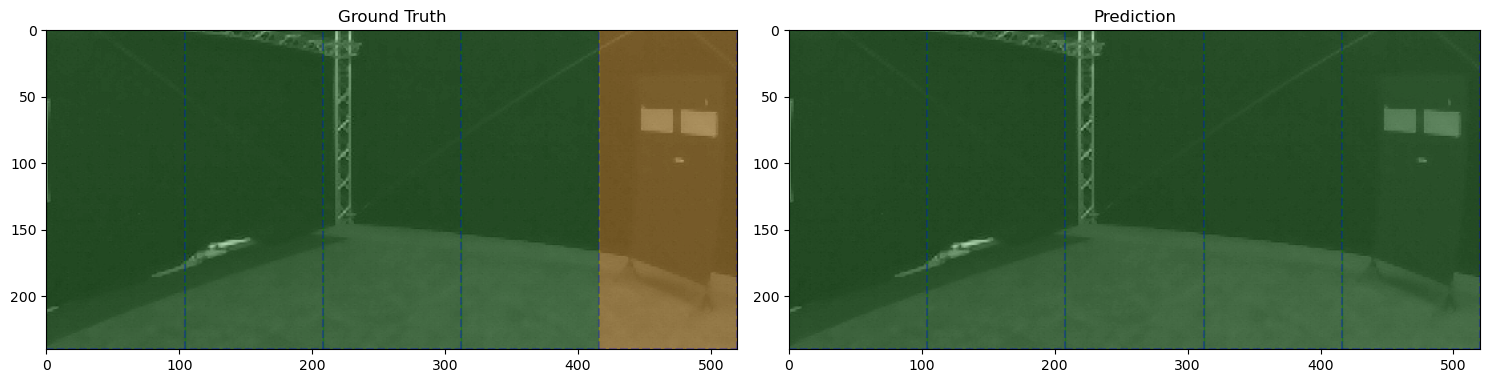


Predictions for sample 1
Cell [0,0]: Safe (1.000)
Cell [1,0]: Safe (1.000)
Cell [2,0]: Safe (1.000)
Cell [3,0]: Safe (1.000)
Cell [4,0]: Safe (1.000)

=== Sample 2 ===


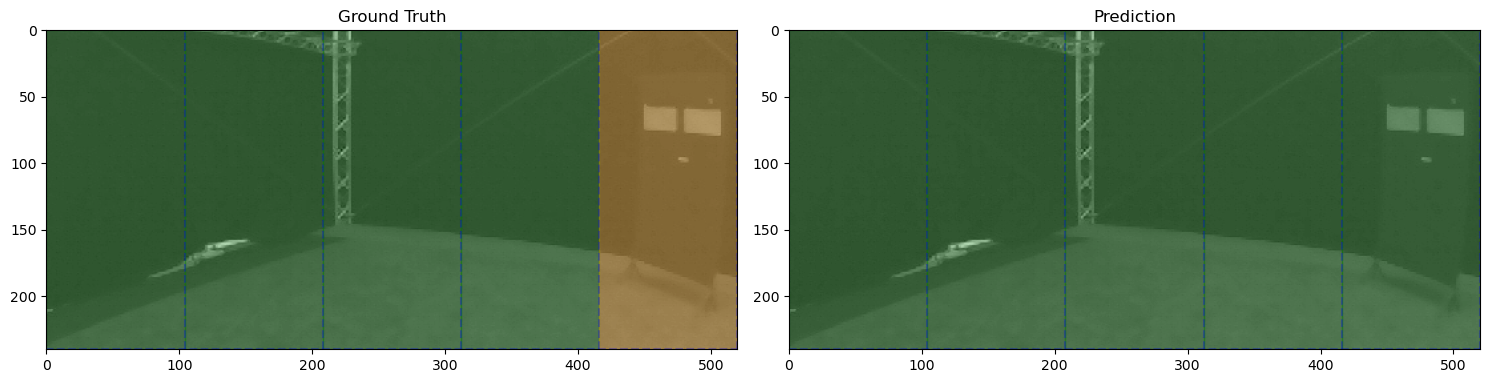


Predictions for sample 2
Cell [0,0]: Safe (1.000)
Cell [1,0]: Safe (1.000)
Cell [2,0]: Safe (1.000)
Cell [3,0]: Safe (1.000)
Cell [4,0]: Safe (1.000)

=== Sample 3 ===


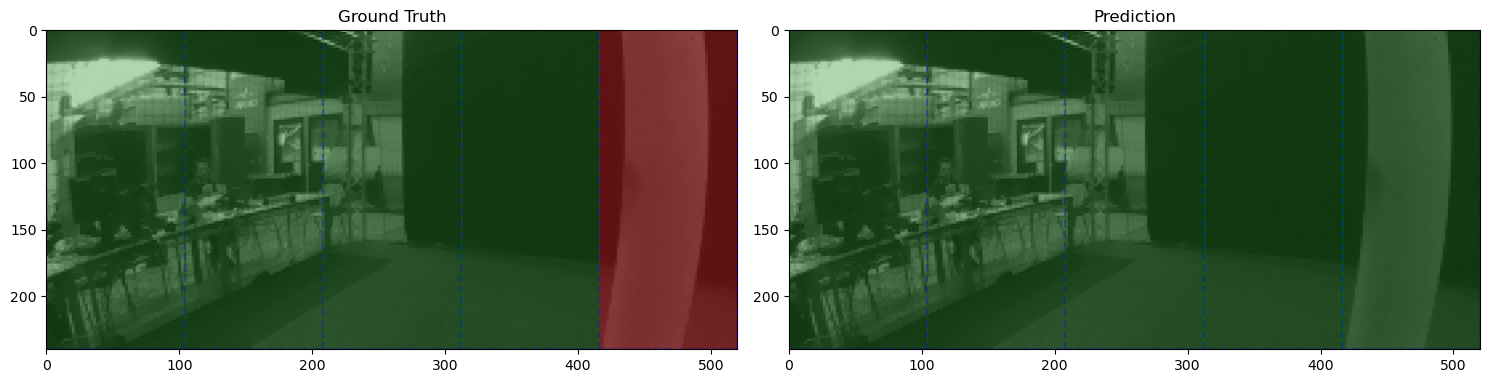


Predictions for sample 3
Cell [0,0]: Safe (1.000)
Cell [1,0]: Safe (1.000)
Cell [2,0]: Safe (1.000)
Cell [3,0]: Safe (1.000)
Cell [4,0]: Safe (1.000)


In [12]:
import matplotlib.pyplot as plt
import torch
import numpy as np

def visualize_predictions(model, data_module, num_samples=3):
    model.eval()
    
    # Get batch
    val_loader = data_module.val_dataloader()
    images, labels = next(iter(val_loader))
    
    # Explicitly reshape to ensure correct dimensions
    images = images.view(images.shape[0], 1, images.shape[1], images.shape[2])
    
    # Get predictions
    with torch.no_grad():
        predictions = torch.sigmoid(model(images))  # Apply sigmoid to get probabilities
    
    # Show only the first num_samples
    for idx in range(min(num_samples, len(images))):
        print(f"\n=== Sample {idx+1} ===")
        
        # Create figure with two subplots side by side
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
        
        # For UYVY format, extract Y values (every second value)
        uyvy_img = images[idx, 0].cpu().numpy()  # [height, width]
        y_img = uyvy_img[:, 1::2]  # Extract Y values
        
        ax1.imshow(y_img, cmap='gray')
        ax2.imshow(y_img, cmap='gray')
        
        # Calculate grid lines for UYVY format
        uyvy_grid_lines = [
            [x for x in data_module.grid_lines[0]], 
            data_module.grid_lines[1]  # y coordinates remain the same
        ]
        
        # Draw grid lines on both plots
        for grid_line_y in uyvy_grid_lines[1]:
            ax1.axhline(grid_line_y, color="blue", linestyle="--", alpha=0.3)
            ax2.axhline(grid_line_y, color="blue", linestyle="--", alpha=0.3)
        for grid_line_x in uyvy_grid_lines[0]:
            ax1.axvline(grid_line_x, color="blue", linestyle="--", alpha=0.3)
            ax2.axvline(grid_line_x, color="blue", linestyle="--", alpha=0.3)
        
        # Get predictions and truth for this sample
        sample_prediction = predictions[idx].cpu().numpy()  # [3, 5, 1]
        sample_truth = labels[idx].cpu().numpy()  # [3, 5, 1]
        
        # Plot ground truth overlaid on left image
        for i in range(sample_truth.shape[1]):  # 5 columns
            for j in range(sample_truth.shape[2]):  # 1 row
                x_start = uyvy_grid_lines[0][i]
                x_end = uyvy_grid_lines[0][i + 1]
                y_start = uyvy_grid_lines[1][j]
                y_end = uyvy_grid_lines[1][j + 1]
                
                if sample_truth[model.danger_config.LEVELS['DANGER'], i, j] > 0.5:  # Danger
                    ax1.fill_between([x_start, x_end], [y_start, y_start], 
                                   [y_end, y_end], color="red", alpha=0.3)
                elif sample_truth[model.danger_config.LEVELS['WARNING'], i, j] > 0.5:  # Warning
                    ax1.fill_between([x_start, x_end], [y_start, y_start], 
                                   [y_end, y_end], color="orange", alpha=0.3)
                elif sample_truth[model.danger_config.LEVELS['SAFE'], i, j] > 0.5:  # Safe
                    ax1.fill_between([x_start, x_end], [y_start, y_start], 
                                   [y_end, y_end], color="green", alpha=0.3)
        
        # Plot predictions overlaid on right image
        for i in range(sample_prediction.shape[1]):  # 5 columns
            for j in range(sample_prediction.shape[2]):  # 1 row
                x_start = uyvy_grid_lines[0][i]
                x_end = uyvy_grid_lines[0][i + 1]
                y_start = uyvy_grid_lines[1][j]
                y_end = uyvy_grid_lines[1][j + 1]
                
                pred_probs = sample_prediction[:, i, j]
                pred_class = np.argmax(pred_probs)
                confidence = pred_probs[pred_class]
                
                if pred_class == model.danger_config.LEVELS['DANGER']:  # Danger
                    color = "red"
                elif pred_class == model.danger_config.LEVELS['WARNING']:  # Warning
                    color = "orange"
                else:  # Safe
                    color = "green"
                
                ax2.fill_between([x_start, x_end], [y_start, y_start], 
                               [y_end, y_end], color=color, alpha=0.3 * confidence)
        
        # Add titles
        ax1.set_title('Ground Truth')
        ax2.set_title('Prediction')
        
        # Set limits for both plots
        ax1.set_xlim(0, y_img.shape[1])
        ax1.set_ylim(y_img.shape[0], 0)
        ax2.set_xlim(0, y_img.shape[1])
        ax2.set_ylim(y_img.shape[0], 0)
        
        plt.tight_layout()
        plt.show()
        
        # Print predictions for this sample
        print("\nPredictions for sample", idx + 1)
        for i in range(sample_prediction.shape[1]):
            for j in range(sample_prediction.shape[2]):
                pred_probs = sample_prediction[:, i, j]
                pred_class = np.argmax(pred_probs)
                confidence = pred_probs[pred_class]
                class_name = ["Safe", "Warning", "Danger"][pred_class]
                print(f"Cell [{i},{j}]: {class_name} ({confidence:.3f})")
                
def create_grid_visualization(data):
    """
    Creates a visualization of the grid predictions/ground truth
    data shape: (3, 5, 1) for 3 classes and 5 grid cells
    Colors: Green for safe, Yellow for warning, Red for danger
    """
    height = 500  # Total height
    width = 100   # Width of visualization
    cell_height = height // 5  # Height per grid cell
    
    # Create RGB image
    img = np.zeros((height, width, 3))
    
    # For each grid cell
    for i in range(5):
        y_start = i * cell_height
        y_end = (i + 1) * cell_height
        
        # Get the predicted class (argmax across the 3 classes)
        cell_state = np.argmax(data[:, i, 0])
        
        # Set color based on state
        if cell_state == 0:  # Safe
            color = [0, 1, 0]  # Green
        elif cell_state == 1:  # Warning
            color = [1, 1, 0]  # Yellow
        else:  # Danger
            color = [1, 0, 0]  # Red
            
        img[y_start:y_end, :] = color
    
    return img

# Visualize some examples
visualize_predictions(model, data_module, num_samples=3)

# Step 3: Evaluate the model on validation set

In [13]:


print("Evaluating model on validation set...")
model.eval()
trainer = pl.Trainer(accelerator='gpu' if torch.cuda.is_available() else 'cpu')
val_results = trainer.validate(model, datamodule=data_module)
print(f"Validation results: {val_results}")


Evaluating model on validation set...


Validation DataLoader 0: 100%|██████████| 4/4 [00:00<00:00,  7.96it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     Validate metric           DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  val_critical_misclass     0.11428571492433548
        val_loss           -0.41948169469833374
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Validation results: [{'val_loss': -0.41948169469833374, 'val_critical_misclass': 0.11428571492433548}]


# Step 4: Visualize some predictions on validation data

In [ ]:

data_module.setup()
val_dataloader = data_module.val_dataloader()

# Get a batch of validation data
val_batch = next(iter(val_dataloader))
images, targets = val_batch

# Move the model to the same device as the input data
device = images.device
model = model.to(device)

# Make predictions
model.eval()
with torch.no_grad():
    predictions = model(images)

# Display a few examples side by side
batch_size = images.shape[0]
num_examples = min(3, batch_size)

for i in range(num_examples):
    # Plot ground truth and prediction side by side
    plot_side_by_side(
        image=images[i],
        ground_truth=targets[i],
        prediction=predictions[i],
        grid_lines=grid_lines,
        example_num=i+1
    )
    plt.show()

# Step 5: Convert the PyTorch model to ONNX

In [ ]:
# Move model to CPU, then convert to ONNX
model = model.to('cpu')
dummy_input = torch.randn(1, 3, height, width, device='cpu')

export_to_onnx(model, input_shape=(1, 3, height, width), output_path="./light_object_detection.onnx")

In [ ]:

# Try loading the model to verify it works
import onnxruntime
ort_session = onnxruntime.InferenceSession("light_object_detection.onnx")

# Test with a sample input
test_input = images[0:1].cpu().numpy()
ort_inputs = {ort_session.get_inputs()[0].name: test_input}
ort_outputs = ort_session.run(None, ort_inputs)

print("Direct ONNX export successful!")

In [ ]:
def run_pytorch_onnx_comparison(model, onnx_path, data_module, num_examples=3):
    """
    Run comparison between PyTorch and ONNX models
    
    Args:
        model: The PyTorch model
        onnx_path: Path to the ONNX model
        data_module: PyTorch Lightning data module
        num_examples: Number of examples to visualize
    """
    # Ensure setup is called
    data_module.setup()
    val_dataloader = data_module.val_dataloader()
    
    # Get a batch of validation data
    val_batch = next(iter(val_dataloader))
    images, targets = val_batch
    
    # Move PyTorch model to CPU for fair comparison with ONNX
    model = model.to('cpu')
    images = images.to('cpu')
    targets = targets.to('cpu')
    
    # Get PyTorch predictions
    model.eval()
    with torch.no_grad():
        pytorch_predictions = model(images)
    
    # Initialize ONNX Runtime session
    ort_session = onnxruntime.InferenceSession(onnx_path)
    input_name = ort_session.get_inputs()[0].name
    
    # Get ONNX predictions
    onnx_inputs = {input_name: images.numpy()}
    onnx_outputs = ort_session.run(None, onnx_inputs)
    onnx_predictions = torch.from_numpy(onnx_outputs[0])
    
    # Display examples side by side
    batch_size = images.shape[0]
    num_examples = min(num_examples, batch_size)
    
    for i in range(num_examples):
        # Plot the comparison
        fig, axes = compare_pytorch_onnx_side_by_side(
            image=images[i],
            ground_truth=targets[i],
            pytorch_pred=pytorch_predictions[i],
            onnx_pred=onnx_predictions[i],
            grid_lines=grid_lines,
            example_num=i+1
        )
        plt.show()
        
        # Print numerical differences
        pt_gt_diff = torch.max(torch.abs(pytorch_predictions[i] - targets[i])).item()
        onnx_gt_diff = torch.max(torch.abs(onnx_predictions[i] - targets[i])).item()
        pt_onnx_diff = torch.max(torch.abs(pytorch_predictions[i] - onnx_predictions[i])).item()
        
        print(f"Example {i+1} - Maximum absolute differences:")
        print(f"  PyTorch vs Ground Truth: {pt_gt_diff:.6f}")
        print(f"  ONNX vs Ground Truth: {onnx_gt_diff:.6f}")
        print(f"  PyTorch vs ONNX: {pt_onnx_diff:.6f}")

# Run the comparison
run_pytorch_onnx_comparison(
    model=model, 
    onnx_path="./object_detection.onnx", 
    data_module=data_module,
    num_examples=3
)

In [ ]:
def compare_models_on_dataset(model, onnx_path, data_module, difference_threshold=0.01):
    """
    Compare PyTorch and ONNX models on the entire validation dataset and 
    find examples where they differ significantly
    
    Args:
        model: The PyTorch model
        onnx_path: Path to the ONNX model
        data_module: PyTorch Lightning data module
        difference_threshold: Threshold to consider a difference significant
    
    Returns:
        list: List of tuples (image, ground_truth, pytorch_pred, onnx_pred, max_diff)
              for examples where the difference exceeds the threshold
    """
    # Ensure setup is called
    data_module.setup()
    val_dataloader = data_module.val_dataloader()
    
    # Move PyTorch model to CPU for fair comparison with ONNX
    model = model.to('cpu')
    model.eval()
    
    # Initialize ONNX Runtime session
    ort_session = onnxruntime.InferenceSession(onnx_path)
    input_name = ort_session.get_inputs()[0].name
    
    # List to store examples with significant differences
    significant_differences = []
    
    # Statistics
    total_examples = 0
    total_correct_match = 0
    difference_histogram = []
    
    # Process all batches
    print("Processing validation dataset...")
    with torch.no_grad():
        for batch_idx, (images, targets) in enumerate(val_dataloader):
            # Move tensors to CPU
            images = images.to('cpu')
            targets = targets.to('cpu')
            
            # Get PyTorch predictions
            pytorch_predictions = model(images)
            
            # Get ONNX predictions
            onnx_inputs = {input_name: images.numpy()}
            onnx_outputs = ort_session.run(None, onnx_inputs)
            onnx_predictions = torch.from_numpy(onnx_outputs[0])
            
            # Compare predictions for each example in the batch
            for i in range(images.shape[0]):
                total_examples += 1
                
                # Calculate max absolute difference
                max_diff = torch.max(torch.abs(pytorch_predictions[i] - onnx_predictions[i])).item()
                difference_histogram.append(max_diff)
                
                # Check if predictions match exactly (after thresholding)
                threshold = 0.5
                pytorch_classes = (pytorch_predictions[i] > threshold).int()
                onnx_classes = (onnx_predictions[i] > threshold).int()
                
                exact_match = torch.all(pytorch_classes == onnx_classes).item()
                if exact_match:
                    total_correct_match += 1
                
                # If difference exceeds threshold, save this example
                if max_diff > difference_threshold or not exact_match:
                    significant_differences.append((
                        images[i].clone(),
                        targets[i].clone(),
                        pytorch_predictions[i].clone(),
                        onnx_predictions[i].clone(),
                        max_diff,
                        exact_match
                    ))
            
            # Print progress every few batches
            if (batch_idx + 1) % 5 == 0 or batch_idx == len(val_dataloader) - 1:
                print(f"Processed {batch_idx+1}/{len(val_dataloader)} batches, "
                      f"found {len(significant_differences)} examples with significant differences")
    
    # Print summary statistics
    print("\nValidation Dataset Summary:")
    print(f"Total examples processed: {total_examples}")
    print(f"Examples with exact class match: {total_correct_match} ({100 * total_correct_match / total_examples:.2f}%)")
    print(f"Examples with significant differences: {len(significant_differences)}")
    
    # Calculate and print difference statistics
    if difference_histogram:
        avg_diff = sum(difference_histogram) / len(difference_histogram)
        max_diff = max(difference_histogram)
        print(f"Average max difference: {avg_diff:.6f}")
        print(f"Maximum difference: {max_diff:.6f}")
    
    return significant_differences

# Run the comparison
significant_differences = compare_models_on_dataset(
    model=model, 
    onnx_path="./light_object_detection.onnx", 
    data_module=data_module,
    difference_threshold=0.0001  # Adjust this threshold as needed
)

print(f"\nFound {len(significant_differences)} examples with significant differences")

In [ ]:
import onnx
import numpy as np
import sys
import os

def analyze_onnx_model(model_path):
    """
    Analyze an ONNX model and print detailed information
    
    Args:
        model_path: Path to the ONNX model file
    """
    print(f"Analyzing ONNX model: {model_path}")
    print("-" * 80)
    
    # Load the ONNX model
    model = onnx.load(model_path)
    
    # Check model validity
    try:
        onnx.checker.check_model(model)
        print("✓ Model is valid")
    except Exception as e:
        print(f"✗ Model is invalid: {e}")
    
    # Basic model info
    print("\n== Model Info ==")
    print(f"IR Version: {model.ir_version}")
    print(f"Producer: {model.producer_name} {model.producer_version}")
    print(f"Domain: {model.domain}")
    print(f"Model Version: {model.model_version}")
    print(f"Doc: {model.doc_string}")
    
    # Count nodes by type
    node_types = {}
    for node in model.graph.node:
        if node.op_type in node_types:
            node_types[node.op_type] += 1
        else:
            node_types[node.op_type] = 1
    
    print("\n== Node Types ==")
    for op_type, count in sorted(node_types.items()):
        print(f"{op_type}: {count}")
    print(f"Total nodes: {len(model.graph.node)}")
    
    # Analyze inputs
    print("\n== Inputs ==")
    for i, input_data in enumerate(model.graph.input):
        name = input_data.name
        shape = []
        for dim in input_data.type.tensor_type.shape.dim:
            if dim.dim_param:
                shape.append(dim.dim_param)
            else:
                shape.append(dim.dim_value)
        print(f"Input #{i}: {name}, Shape: {shape}")
    
    # Analyze outputs
    print("\n== Outputs ==")
    for i, output in enumerate(model.graph.output):
        name = output.name
        shape = []
        for dim in output.type.tensor_type.shape.dim:
            if dim.dim_param:
                shape.append(dim.dim_param)
            else:
                shape.append(dim.dim_value)
        print(f"Output #{i}: {name}, Shape: {shape}")
    
    # Analyze initializers (weights and biases)
    print("\n== Initializers (Parameters) ==")
    total_params = 0
    total_size_bytes = 0
    
    for i, initializer in enumerate(model.graph.initializer):
        shape = [dim for dim in initializer.dims]
        num_params = np.prod(shape)
        total_params += num_params
        
        # Calculate memory size
        elem_type = initializer.data_type
        bytes_per_element = 4  # Default for float32
        if elem_type == 1:  # FLOAT
            bytes_per_element = 4
        elif elem_type == 2:  # UINT8
            bytes_per_element = 1
        elif elem_type == 3:  # INT8
            bytes_per_element = 1
        elif elem_type == 5:  # INT16
            bytes_per_element = 2
        elif elem_type == 6:  # INT32
            bytes_per_element = 4
        elif elem_type == 7:  # INT64
            bytes_per_element = 8
        elif elem_type == 10:  # FLOAT16
            bytes_per_element = 2
        elif elem_type == 11:  # DOUBLE
            bytes_per_element = 8
            
        param_size_bytes = num_params * bytes_per_element
        total_size_bytes += param_size_bytes
        
        print(f"Initializer #{i}: {initializer.name}")
        print(f"  Shape: {shape}, Elements: {num_params}, Size: {format_bytes(param_size_bytes)}")
    
    print(f"\nTotal parameters: {total_params:,}")
    print(f"Total parameter size: {format_bytes(total_size_bytes)}")
    
    # Estimate C file size (parameters + overhead)
    estimated_c_file_size = total_size_bytes * 7  # Rough estimate based on float representation in C
    print(f"Estimated C file size: {format_bytes(estimated_c_file_size)} (rough estimate)")
    
    print("\n== Memory Analysis ==")
    print(f"Parameter memory: {format_bytes(total_size_bytes)}")
    
    # Estimate activation memory based on intermediate tensors
    # This is a rough estimation
    activation_memory = 0
    for node in model.graph.node:
        for output in node.output:
            # Find corresponding value info if available
            for value_info in model.graph.value_info:
                if value_info.name == output:
                    shape = [dim.dim_value for dim in value_info.type.tensor_type.shape.dim]
                    if all(shape):  # Only count if we have complete shape info
                        activation_memory += np.prod(shape) * 4  # Assuming float32
    
    print(f"Activation memory (estimated): {format_bytes(activation_memory)}")
    print(f"Total memory footprint (estimated): {format_bytes(total_size_bytes + activation_memory)}")

def format_bytes(size):
    """Format bytes to human-readable string"""
    for unit in ['B', 'KB', 'MB', 'GB']:
        if size < 1024.0 or unit == 'GB':
            return f"{size:.2f} {unit}"
        size /= 1024.0

analyze_onnx_model('light_object_detection.onnx')

# Convert ONNX model to C using ONNX2C (Ubuntu only)

Setup docker with the docker file in the folder (make sure working directory contains the docker file):

```  sudo docker build -t onnx2c-fixed . ```

```sudo docker run --rm -v $(pwd):/data onnx2c-fixed light_object_detection.onnx > light_object_detection.c```


# Validate the C model with our onnx model

Loading image: Dataset/dataset_syn/images/train/19049365.jpg
Image preprocessed to shape: (1, 3, 240, 520)
Saving input tensor to: C:\Users\danie\AppData\Local\Temp\temp_input.bin
Running ONNX model: light_object_detection.onnx
Running C model: build/Debug/model_runner_grid.exe
C model output: Model output summary:
Danger level 0:
  Column 0: 0.3606
  Column 1: 0.1405
  Column 2: 0.4595
  Column 3: 0.7692
  Column 4: 0.5571
Danger level 1:
  Column 0: 0.3016
  Column 1: 0.1339
  Column 2: 0.3754
  Column 3: 0.6763
  Column 4: 0.0510
Danger level 2:
  Column 0: 0.1366
  Column 1: 0.0480
  Column 2: 0.1357
  Column 3: 0.1576
  Column 4: 0.0268

Both models ran successfully! Comparing results...

Differences between ONNX and C predictions:
  Maximum absolute difference: 0.000001
  Average absolute difference: 0.000000

Detailed grid values:

Safe Level:
  ONNX values:
    Row 0: 0.3606, 0.1405, 0.4595, 0.7692, 0.5571
  C values:
    Row 0: 0.3606, 0.1405, 0.4595, 0.7692, 0.5571

Warning L

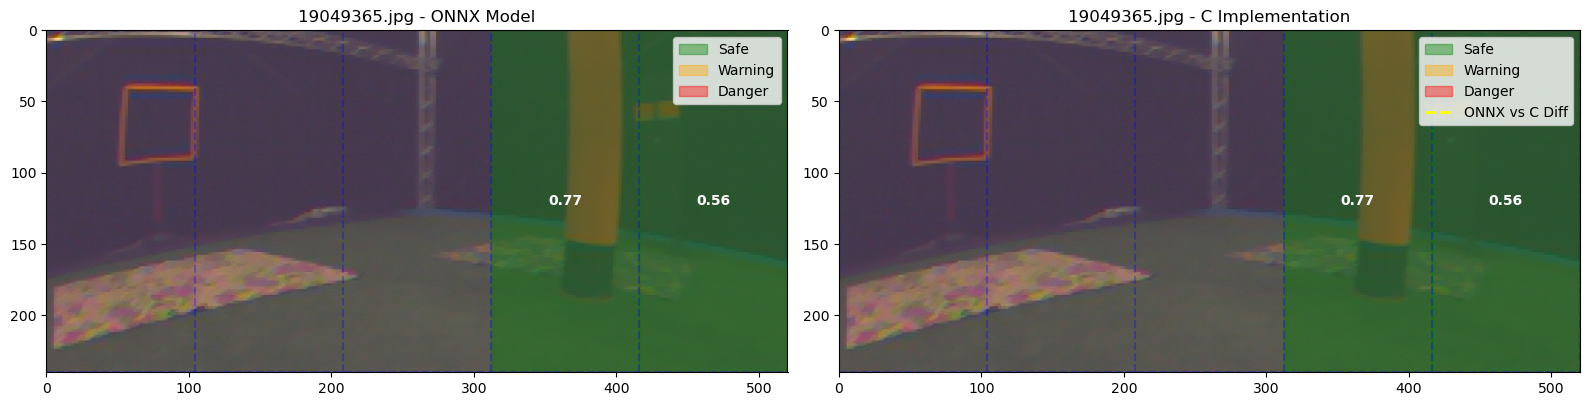

In [128]:
# ONNX vs C Grid Model Comparison Notebook

import os
import subprocess
import numpy as np
import matplotlib.pyplot as plt
import onnxruntime
import tempfile
from PIL import Image
import cv2

# Configuration
onnx_model_path = "light_object_detection.onnx"  # Update with your grid-based ONNX model path
c_executable = "build/Debug/model_runner_grid.exe"   # Update with your executable path
# You'll need to provide a test image path when running

def load_and_preprocess_image(image_path, target_size=(520, 240)):
    """Load and preprocess an image for the model"""
    # Load image
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError(f"Could not load image from {image_path}")
    
    # Convert BGR to RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Resize image to target size
    img = cv2.resize(img, (target_size[0], target_size[1]))
    
    # Convert to float32 and normalize to [0, 1]
    img = img.astype(np.float32) / 255.0
    
    # Convert to NCHW format
    img = img.transpose(2, 0, 1)
    
    # Add batch dimension
    img = np.expand_dims(img, axis=0)
    
    return img, img[0].transpose(1, 2, 0)  # Return both NCHW and HWC versions

def save_input_to_bin(input_tensor, output_file):
    """Save input tensor to binary file for C model"""
    flat_input = input_tensor.flatten()
    flat_input.tofile(output_file)
    return output_file

def run_c_model(exe_path, input_file, output_file):
    """Run the C model executable"""
    try:
        result = subprocess.run(
            [exe_path, input_file, output_file],
            check=True,
            capture_output=True,
            text=True
        )
        if result.stdout:
            print("C model output:", result.stdout)
        if result.stderr:
            print("C model errors:", result.stderr)
        
        # Load the output binary file
        if os.path.exists(output_file):
            output = np.fromfile(output_file, dtype=np.float32)
            # Reshape to match the grid-based output format [1, 3, 5, 1]
            output = output.reshape(1, 3, 5, 1)
            return output
        else:
            print(f"Error: C model output file '{output_file}' was not created")
            return None
    except subprocess.CalledProcessError as e:
        print(f"Error running C model: {e}")
        if e.stdout:
            print("stdout:", e.stdout)
        if e.stderr:
            print("stderr:", e.stderr)
        return None

def run_onnx_model(onnx_path, input_tensor):
    """Run ONNX model using ONNX Runtime"""
    try:
        ort_session = onnxruntime.InferenceSession(onnx_path)
        input_name = ort_session.get_inputs()[0].name
        
        # Run inference
        onnx_inputs = {input_name: input_tensor}
        onnx_outputs = ort_session.run(None, onnx_inputs)
        
        # Get and reshape the output (should already be [1, 3, 5, 1])
        onnx_result = np.array(onnx_outputs[0])
        
        return onnx_result
    except Exception as e:
        print(f"Error running ONNX model: {e}")
        return None

def compare_grid_predictions(image, onnx_pred, c_pred, title=None):
    """
    Plot ONNX and C model grid predictions side by side
    
    Args:
        image: Display image (H, W, C)
        onnx_pred: ONNX model prediction of shape (1, 3, 5, 1)
        c_pred: C model prediction of shape (1, 3, 5, 1)
        title: Optional title
    """
    # Create a figure with two subplots side by side
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
    
    # Plot base images
    ax1.imshow(image)
    ax1.set_title("ONNX Model Prediction" if title is None else f"{title} - ONNX Model")
    
    ax2.imshow(image)
    ax2.set_title("C Implementation" if title is None else f"{title} - C Implementation")
    
    # Generate grid lines
    img_h, img_w = image.shape[:2]
    grid_x = onnx_pred.shape[2]  # Number of columns (5)
    grid_y = onnx_pred.shape[3]  # Number of rows (1)
    
    # Calculate grid line positions
    x_lines = [int(i * img_w / grid_x) for i in range(grid_x + 1)]
    y_lines = [int(i * img_h / grid_y) for i in range(grid_y + 1)]
    
    # Draw grid lines on both plots
    for x in x_lines:
        ax1.axvline(x, color='blue', linestyle='--', alpha=0.3)
        ax2.axvline(x, color='blue', linestyle='--', alpha=0.3)
    for y in y_lines:
        ax1.axhline(y, color='blue', linestyle='--', alpha=0.3)
        ax2.axhline(y, color='blue', linestyle='--', alpha=0.3)
    
    # Define danger level names and colors
    danger_levels = ["Safe", "Warning", "Danger"]
    colors = ['green', 'orange', 'red']
    
    # Define threshold for visualization
    threshold = 0.5
    
    # Draw grid cells on ONNX prediction (left)
    for i in range(grid_x):
        for j in range(grid_y):
            x1, x2 = x_lines[i], x_lines[i + 1]
            y1, y2 = y_lines[j], y_lines[j + 1]
            
            # Find the danger level with highest confidence
            max_level = -1
            max_conf = 0.0
            
            for level in range(len(danger_levels)):
                conf = float(onnx_pred[0, level, i, j])
                if conf > max_conf:
                    max_conf = conf
                    max_level = level
            
            # Fill cell with color based on highest confidence danger level
            if max_conf > threshold:
                ax1.fill_between([x1, x2], [y1, y1], [y2, y2], 
                                color=colors[max_level], alpha=0.4)
                
                # Add text label showing confidence
                center_x = (x1 + x2) // 2
                center_y = (y1 + y2) // 2
                ax1.text(center_x, center_y, f"{max_conf:.2f}", 
                        ha='center', va='center', 
                        color='white', fontweight='bold')
    
    # Draw grid cells on C prediction (right)
    for i in range(grid_x):
        for j in range(grid_y):
            x1, x2 = x_lines[i], x_lines[i + 1]
            y1, y2 = y_lines[j], y_lines[j + 1]
            
            # Find the danger level with highest confidence
            max_level = -1
            max_conf = 0.0
            
            for level in range(len(danger_levels)):
                conf = float(c_pred[0, level, i, j])
                if conf > max_conf:
                    max_conf = conf
                    max_level = level
            
            # Fill cell with color based on highest confidence danger level
            if max_conf > threshold:
                ax2.fill_between([x1, x2], [y1, y1], [y2, y2], 
                                color=colors[max_level], alpha=0.4)
                
                # Add text label showing confidence
                center_x = (x1 + x2) // 2
                center_y = (y1 + y2) // 2
                ax2.text(center_x, center_y, f"{max_conf:.2f}", 
                        ha='center', va='center',
                        color='white', fontweight='bold')
                
            # Find ONNX model's prediction for comparison
            onnx_max_level = -1
            onnx_max_conf = 0.0
            
            for level in range(len(danger_levels)):
                conf = float(onnx_pred[0, level, i, j])
                if conf > onnx_max_conf:
                    onnx_max_conf = conf
                    onnx_max_level = level
            
            # Highlight differences between ONNX and C predictions with yellow outline
            if ((onnx_max_conf > threshold) != (max_conf > threshold) or 
                (onnx_max_conf > threshold and max_conf > threshold and onnx_max_level != max_level)):
                ax2.plot([x1, x2, x2, x1, x1], [y1, y1, y2, y2, y1], 'y--', linewidth=2)
    
    # Add legend
    handles = [
        plt.Rectangle((0, 0), 1, 1, color='green', alpha=0.4, label='Safe'),
        plt.Rectangle((0, 0), 1, 1, color='orange', alpha=0.4, label='Warning'),
        plt.Rectangle((0, 0), 1, 1, color='red', alpha=0.4, label='Danger'),
        plt.Line2D([], [], color='yellow', linestyle='--', linewidth=2, label='ONNX vs C Diff')
    ]
    
    ax1.legend(handles=handles[:3], loc='upper right')
    ax2.legend(handles=handles, loc='upper right')
    
    # Set axes limits
    ax1.set_xlim(0, img_w)
    ax1.set_ylim(img_h, 0)  # Inverted y-axis for image coordinates
    ax2.set_xlim(0, img_w)
    ax2.set_ylim(img_h, 0)
    
    plt.tight_layout()
    
    # Print numerical differences between ONNX and C predictions
    if onnx_pred is not None and c_pred is not None:
        diff = np.abs(onnx_pred - c_pred)
        max_diff = np.max(diff)
        avg_diff = np.mean(diff)
        print("\nDifferences between ONNX and C predictions:")
        print(f"  Maximum absolute difference: {max_diff:.6f}")
        print(f"  Average absolute difference: {avg_diff:.6f}")
        
        # Print detailed grid values
        print("\nDetailed grid values:")
        for level_idx, level_name in enumerate(danger_levels):
            print(f"\n{level_name} Level:")
            
            print("  ONNX values:")
            for j in range(grid_y):
                row_vals = [f"{onnx_pred[0, level_idx, i, j]:.4f}" for i in range(grid_x)]
                print(f"    Row {j}: {', '.join(row_vals)}")
            
            print("  C values:")
            for j in range(grid_y):
                row_vals = [f"{c_pred[0, level_idx, i, j]:.4f}" for i in range(grid_x)]
                print(f"    Row {j}: {', '.join(row_vals)}")
    
    return fig, (ax1, ax2)

def compare_and_visualize(image_path):
    """Run comparison on the given image and visualize results"""
    # Check if files exist
    for path, name in [(image_path, 'Image'), (onnx_model_path, 'ONNX model'), (c_executable, 'C executable')]:
        if not os.path.exists(path):
            print(f"Error: {name} file '{path}' does not exist")
            return
    
    # Load and preprocess image
    print(f"Loading image: {image_path}")
    try:
        # Preprocess for model
        input_tensor, display_img = load_and_preprocess_image(image_path)
        print(f"Image preprocessed to shape: {input_tensor.shape}")
    except Exception as e:
        print(f"Error loading image: {e}")
        return
    
    # Create temporary files for C model
    temp_input = os.path.join(tempfile.gettempdir(), "temp_input.bin")
    temp_output = os.path.join(tempfile.gettempdir(), "temp_output.bin")
    
    # Save input tensor to binary file
    print(f"Saving input tensor to: {temp_input}")
    save_input_to_bin(input_tensor, temp_input)
    
    # Run ONNX model
    print(f"Running ONNX model: {onnx_model_path}")
    onnx_result = run_onnx_model(onnx_model_path, input_tensor)
    
    # Run C model
    print(f"Running C model: {c_executable}")
    c_result = run_c_model(c_executable, temp_input, temp_output)
    
    # Compare results
    if onnx_result is not None and c_result is not None:
        print("Both models ran successfully! Comparing results...")
        fig, _ = compare_grid_predictions(
            image=display_img,
            onnx_pred=onnx_result,
            c_pred=c_result,
            title=os.path.basename(image_path)
        )
        plt.show()
    else:
        if onnx_result is None:
            print("Failed to get results from ONNX model")
        if c_result is None:
            print("Failed to get results from C model")
    
    # Clean up temporary files
    for temp_file in [temp_input, temp_output]:
        if os.path.exists(temp_file):
            os.remove(temp_file)

# Example usage (call this with your image path)
compare_and_visualize("Dataset/dataset_syn/images/train/19049365.jpg")